# Collecting data

In [2]:
from gwosc.datasets import event_gps

# Parameter to change
name_event = 'GW170817' # Event name
fmin = 20 # lowest frequency event
fmax = 1000 # highest frequency event

In [3]:
# Get the GPS time for the event
gps = event_gps(name_event)

# segment of time to get around the GPS time
segment = (int(gps)-4, int(gps)+4)

In [4]:
from gwpy.timeseries import TimeSeries

available_data = []
detector = 0

# collect data online
try:
    hdata = TimeSeries.fetch_open_data('H1', *segment, cache=True) # collect Handford data
    if hdata[0] != 'nan': # check if data is not empty and assign it to list 
        available_data.append(hdata)
        detector += 1
except:
    hdata = None
    print('No data from H1')

try:
    ldata = TimeSeries.fetch_open_data('L1', *segment, cache=True) # collect Livingston data
    if ldata[0] != 'nan': # check if data is not empty and assign it to list
        available_data.append(ldata)
        detector += 1 
except:
    ldata = None
    print('No data from L1')

try:
    vdata = TimeSeries.fetch_open_data('V1', *segment, cache=True) # collect Virgo data
    if vdata[0] != 'nan': # check if data is not empty and assign it to list
        available_data.append(vdata)
        detector += 1
except:
    vdata = None
    print('No data from V1')
try:
    gdata = TimeSeries.fetch_open_data('G1', *segment, cache=True) # collect GEO600 data
    if gdata[0] != 'nan': # check if data is not empty and assign it to list
        available_data.append(gdata)
except:
    gdata = None
    print('No data from G1')

/home/val/anaconda3/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


# Collecting LIGO's estimate (distance + mass)

In [5]:
from gwosc.datasets import find_datasets
from gwosc.api import fetch_event_json

# Find all datasets associated with the event name
datasets = find_datasets(type='event', detector=None, segment=segment)

# Find the newest dataset
if datasets:
    datasets.sort(reverse=True)  # Sort by string, to get newest first

    # Get the newest version of the event
    newest_event_name = datasets[0]

    # Get event parameters
    event_data = fetch_event_json(newest_event_name)

    # Extract distance and uncertainties from the event data
    distance = event_data['events'][newest_event_name].get('luminosity_distance')
    distance_lower = event_data['events'][newest_event_name].get('luminosity_distance_lower')
    distance_upper = event_data['events'][newest_event_name].get('luminosity_distance_upper')
    
    # Extract masses and uncertainties from event data
    mass1 = event_data['events'][newest_event_name].get('mass_1_source')
    mass1_lower = event_data['events'][newest_event_name].get('mass_1_source_lower')
    mass1_upper = event_data['events'][newest_event_name].get('mass_1_source_upper')
    
    mass2 = event_data['events'][newest_event_name].get('mass_2_source')
    mass2_lower = event_data['events'][newest_event_name].get('mass_2_source_lower')
    mass2_upper = event_data['events'][newest_event_name].get('mass_2_source_upper')

    if distance is not None:
        print(f"Distance to {newest_event_name}: {distance} Mpc")
        print(f"Uncertainty: {distance_lower} Mpc, +{distance_upper} Mpc")
        print('')
    else:
        print(f"No distance data available for {newest_event_name}")
        print('')
        
    if mass1 is not None:
        print(f"mass 1 of {newest_event_name}: {mass1} M_Sun")
        print(f"Uncertainty: {mass1_lower} M_Sun, +{mass1_upper} M_Sun")
        print('')
    else:
        print(f"No mass 1 data available for {newest_event_name}")
        print('')
        
    if mass2 is not None:
        print(f"mass 2 of {newest_event_name}: {mass2} M_Sun")
        print(f"Uncertainty: {mass2_lower} M_Sun, +{mass2_upper} M_Sun")
        print('')
    else:
        print(f"No mass 2 data available for {newest_event_name}")
        print('')
else:
    print(f"Could not find a dataset for event: {name_event}")

Distance to GW170817-v3: 40.0 Mpc
Uncertainty: -15.0 Mpc, +7.0 Mpc

mass 1 of GW170817-v3: 1.46 M_Sun
Uncertainty: -0.1 M_Sun, +0.12 M_Sun

mass 2 of GW170817-v3: 1.27 M_Sun
Uncertainty: -0.09 M_Sun, +0.09 M_Sun



# Estimate priors distances for Bayesian Inference

In [6]:
from gwpy.timeseries import TimeSeries
from gwpy.astro import inspiral_range

D_range_low = []
D_range_high = []
    
for i in range(0,2):
    hoff = available_data[i].psd(fftlength=4) # get Power Spectral Density from data
    r1 = inspiral_range(hoff, fmin=fmin, fmax=fmax, mass1=mass1, mass2=mass2) # calculate inspiral range at which event can be detected
    try:
        r2 = inspiral_range(hoff, mass1=mass1, mass2=mass2)
    except:
        r2 = r1

    SNR_threshold = 9 # SNR threshold set based on article 
    SNR_measured = event_data['events'][newest_event_name].get('network_matched_filter_snr') # get measured SNR from LIGO's database

    
    D_range_low.append(r1 * SNR_threshold/SNR_measured)
    D_range_high.append(r2)

In [7]:
import numpy as np

low_distance = np.mean([d.value for d in D_range_low]) # calculate average for low distance estimate
high_distance = np.mean([d.value for d in D_range_high]) # calculate average for high distance estimate

print(f"Low distance estimate:{low_distance} Mpc")
print(f"High distance estimate:{high_distance} Mpc")

Low distance estimate:14.328556788365582 Mpc
High distance estimate:95.4005672322794 Mpc


# Collect data

In [8]:
strain_data = event_data['events'][newest_event_name].get('strain') # get a list of all the available parameters and urls for this event
detectors = ['H1', 'L1', 'V1', 'G1'] # List of detectors 

# Filter URLs for sampling rate 4096 and duration 32s
filtered_urls = []
for file_info in strain_data:
    if file_info['sampling_rate'] == 4096 and file_info['duration'] == 32 and file_info['format'] == 'gwf':
        if any(detector in file_info['detector'] for detector in detectors):
            filtered_urls.append(file_info['url'])

In [9]:
# assign available urls to variable
gdata = hdata = ldata = vdata = None
for url in filtered_urls:
    if "H-H1" in url:
        hdata = url
    elif "L-L1" in url:
        ldata = url
    elif "V-V1" in url:
        vdata = url
    elif "G-G1" in url:
        gdata = url

In [10]:
from pycbc.psd import inverse_spectrum_truncation
from pycbc.frame import read_frame
from pycbc.filter import highpass, resample_to_delta_t
from astropy.utils.data import download_file

url_map = {'H1': hdata, 'L1': ldata, 'V1': vdata, 'G1': gdata}

# Initialise dictionaries for storing data
data_filenames = {}
psds = {}
data = {}

# Loop through each detector to get url
for detector in detectors:
    print(f"Processing {detector} data")
    
    # Get the url for available detector
    url = url_map.get(detector)
    
    # Check if url is None
    if url is None:
        print(f"No URL available for {detector}")
        continue

    # Download the file
    fname = download_file(url, cache=True)
    data_filenames[detector] = fname

    # Load the time series data for 4 seconds before and after the event
    ts = read_frame(fname, f"{detector}:GWOSC-4KHZ_R1_STRAIN",
                    start_time=int(gps - 4),
                    end_time=int(gps + 4))
    
    # Estimate and process the power spectral density (PSD)
    psd = ts.psd(4)
    psd = inverse_spectrum_truncation(psd, int(4 * psd.sample_rate), 
                                      trunc_method='welch', 
                                      low_frequency_cutoff=fmin)

    # Preprocess the data: high-pass filter, resample, and convert to frequency series
    ts = highpass(ts, fmin) # Remove low-frequency content
    data[detector] = resample_to_delta_t(ts, 1.0 / 2048) # Resample to 2048 Hz

Processing H1 data
Processing L1 data
Processing V1 data
Processing G1 data


# Set up Inference

In [11]:
from pycbc.inference import sampler
from pycbc.distributions import Uniform
from pycbc.inference.sampler import emcee_pt
approximant = 'TaylorF2'

In [12]:
# configure model file
model_config = f"""
[model]
name = single_template
low-frequency-cutoff = {fmin}
high-frequency-cutoff = {fmax}
"""

!echo '{model_config}' > model.ini
!cat model.ini


[model]
name = single_template
low-frequency-cutoff = 20
high-frequency-cutoff = 1000



In [13]:
# Get only detectors that have data
available_detectors = {detector: path for detector, path in data_filenames.items() if path}

# Prepare the instruments and frame-files strings based on available detector 
instruments = ' '.join(available_detectors.keys())
frame_files = ' '.join(f"{det}:{path}" for det, path in available_detectors.items())
channels = ' '.join(f"{det}:GWOSC-4KHZ_R1_STRAIN" for det in available_detectors.keys())

# Create the data configuration
data_config = f"""
[data]
instruments = {instruments}
trigger-time = {gps}
analysis-start-time = -4
analysis-end-time = 4
psd-estimation = median
psd-start-time = -4
psd-end-time = 4
psd-segment-length = 4
psd-segment-stride = 2
psd-inverse-length = 4
strain-high-pass = {fmin}
sample-rate = 2048
frame-files = {frame_files}
channel-name = {channels}
"""

!echo '{data_config}' > data.ini
!cat data.ini


[data]
instruments = H1 L1 V1 G1
trigger-time = 1187008882.4
analysis-start-time = -4
analysis-end-time = 4
psd-estimation = median
psd-start-time = -4
psd-end-time = 4
psd-segment-length = 4
psd-segment-stride = 2
psd-inverse-length = 4
strain-high-pass = 20
sample-rate = 2048
frame-files = H1:/home/val/.astropy/cache/download/url/ccee0e40e6ff0f0da82895426f6a4ecd/contents L1:/home/val/.astropy/cache/download/url/a5baef54d68a6d37f7b19d977b112d08/contents V1:/home/val/.astropy/cache/download/url/aed20627361df4640df442e771816082/contents G1:/home/val/.astropy/cache/download/url/0875458fe3e598ac2662d599814a0199/contents
channel-name = H1:GWOSC-4KHZ_R1_STRAIN L1:GWOSC-4KHZ_R1_STRAIN V1:GWOSC-4KHZ_R1_STRAIN G1:GWOSC-4KHZ_R1_STRAIN



In [14]:
# create prior parameter file
prior_config = f"""
[variable_params]
distance =
inclination =
ra = 
dec =

[static_params]
mass1 = {mass1}
mass2 = {mass2}
f_lower = 80
approximant = {approximant}
polarization = 90
tc = {gps}

[prior-distance]
name = uniform
min-distance = {low_distance}
max-distance = {high_distance}

[prior-inclination]
name = sin_angle

[prior-ra+dec]
name = uniform_sky
"""
!echo '{prior_config}' > prior.ini
!cat prior.ini


[variable_params]
distance =
inclination =
ra = 
dec =

[static_params]
mass1 = 1.46
mass2 = 1.27
f_lower = 80
approximant = TaylorF2
polarization = 90
tc = 1187008882.4

[prior-distance]
name = uniform
min-distance = 14.328556788365582
max-distance = 95.4005672322794

[prior-inclination]
name = sin_angle

[prior-ra+dec]
name = uniform_sky



In [15]:
# create the sampler file
sampler_config = f"""
[sampler]
name = emcee_pt
ntemps=6
nwalkers=500
niterations=600
"""

!echo '{sampler_config}' > sampler.ini
!cat sampler.ini


[sampler]
name = emcee_pt
ntemps=6
nwalkers=500
niterations=600



# Do Inference

In [16]:
# run inference
!pycbc_inference --verbose \
    --config-files model.ini data.ini prior.ini sampler.ini \
    --output-file inference.hdf \
    --nprocesses 8 \
    --force    

2025-04-23T15:59:17.415+01:00 INFO : Using seed 0
2025-04-23T15:59:17.416+01:00 INFO : Running with CPU support: 1 threads
2025-04-23T15:59:17.416+01:00 INFO : Reading configuration file
2025-04-23T15:59:17.420+01:00 INFO : Setting up model
2025-04-23T15:59:17.425+01:00 INFO : Setting up priors for each parameter
2025-04-23T15:59:17.425+01:00 WARNING : No sampling_params section read from config file
2025-04-23T15:59:17.428+01:00 INFO : Determining analysis times to use
2025-04-23T15:59:17.428+01:00 INFO : Padding H1 analysis start and end times by 2 (= psd-inverse-length/2) seconds to account for PSD wrap around effects.
2025-04-23T15:59:17.429+01:00 INFO : Padding L1 analysis start and end times by 2 (= psd-inverse-length/2) seconds to account for PSD wrap around effects.
2025-04-23T15:59:17.429+01:00 INFO : Padding V1 analysis start and end times by 2 (= psd-inverse-length/2) seconds to account for PSD wrap around effects.
2025-04-23T15:59:17.429+01:00 INFO : Padding G1 analysis sta

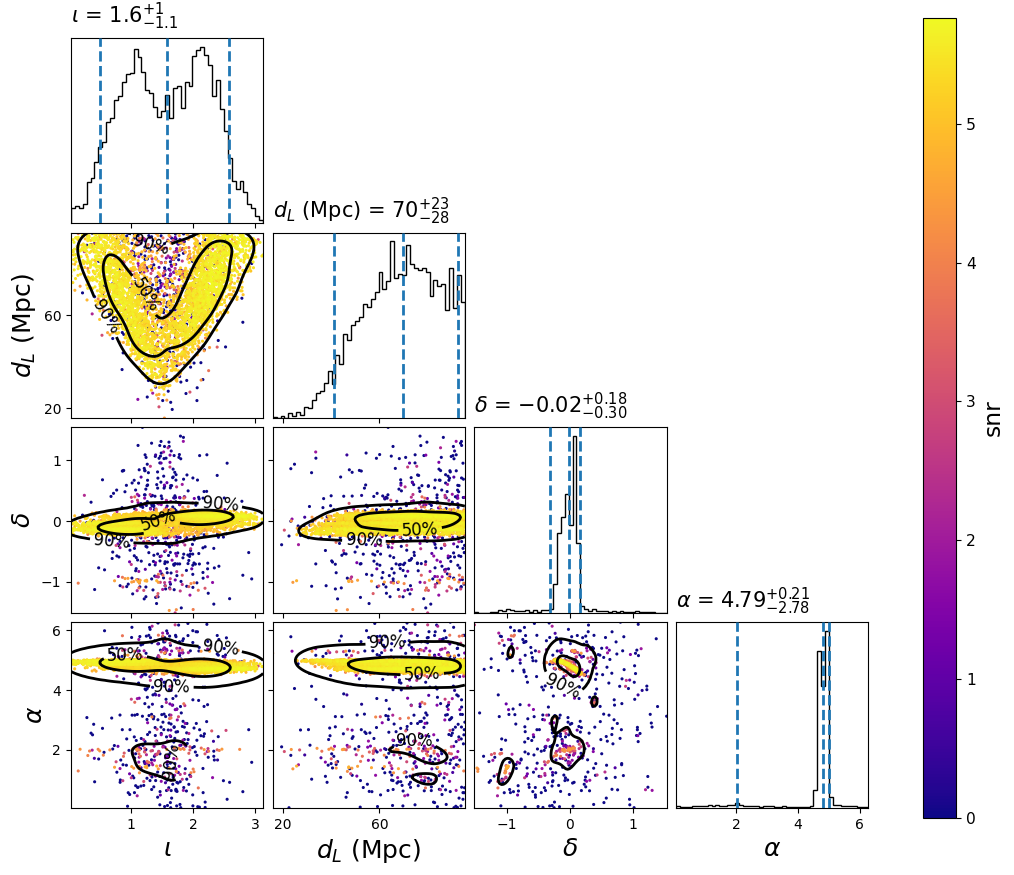

In [17]:
# plot a corner plot of the results from inference 
!pycbc_inference_plot_posterior --input-file inference.hdf \
    --output-file posterior.png \
    --plot-contours --plot-marginal \
    --plot-scatter --plot-marginal --z-arg snr

from IPython.display import Image
Image('posterior.png', height=480)

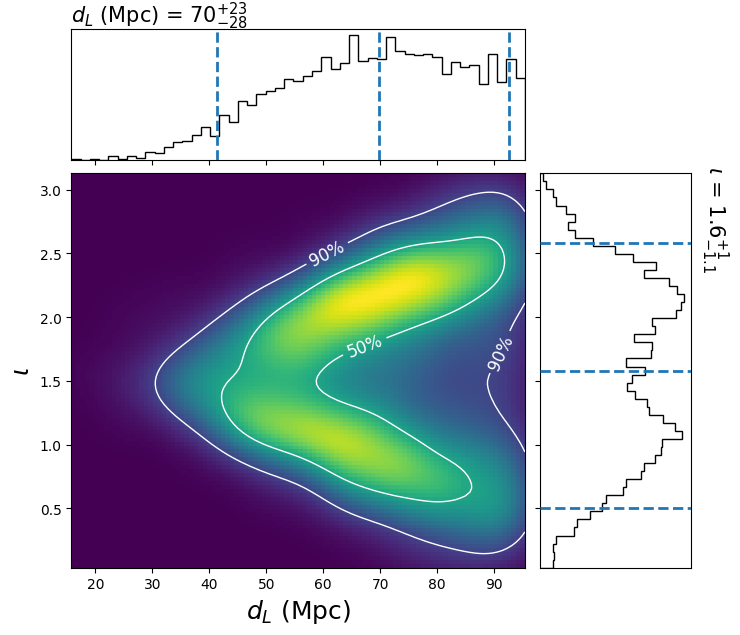

In [18]:
# plot a density map of distance and inclination
!pycbc_inference_plot_posterior --input-file inference.hdf \
    --output-file posterior-dist_inc.png \
    --plot-density --plot-contours --plot-marginal \
    --parameters distance inclination 

Image('posterior-dist_inc.png')